# 05 — Transformer para Classificação de EEG

Este notebook treina um **Transformer Encoder-Only** para classificar estados mentais a partir das features espectrais do EEG.

## Estratégia: Canal como token

Diferente da CNN (que trata as 25 features como uma grade espacial 5×5) e da LSTM (que trata as bandas como sequência temporal), o Transformer usa **cada canal EEG como um token**:

```
(N, 25) → reshape → (N, 5_canais, 5_bandas)
                         ↑ tokens     ↑ features por token
         AF3, AF4, T7, T8, Pz
```

O mecanismo de **self-attention** aprende correlações entre os 5 eletrodos:
- **AF3 ↔ AF4**: frontais simétricos
- **T7 ↔ T8**: temporais simétricos — principais em motor imagery
- **Pz**: parietal — comportamento distinto nos outros canais

## Arquitetura

```
Input(5, 5)
  → Dense(d_model=64)            # embedding linear por token
  → Learnable Positional Emb.    # identidade de cada canal
  → Prepend [CLS] token          # sequência: 6 tokens
  → 2× TransformerEncoderBlock   # pre-norm: LN → MHA → Add, LN → FFN → Add
  → Extrai [CLS]                 # representação global
  → LN → Dropout → Dense(3)      # classificação
```

Os dados utilizados são os gerados pelo notebook `02_preprocessamento_base.ipynb`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.models.transformer import TransformerConfig, build_transformer_model, train_transformer

## Carregar dados pré-processados

In [3]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

X_train = np.load(PROCESSED_DIR / "X_train_base.npy")
X_test  = np.load(PROCESSED_DIR / "X_test_base.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_test  = np.load(PROCESSED_DIR / "y_test.npy")

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (68388, 25)
X_test:  (17097, 25)
y_train: (68388,)
y_test:  (17097,)


---
## Treinamento do Transformer

### Hiperparâmetros

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `d_model` | 64 | Proporcional ao tamanho do token (5 features) — não inflar |
| `num_heads` | 4 | Power-of-2, divide d_model — 4 perspectivas de atenção entre canais |
| `num_layers` | 2 | Sequência curta (5 tokens) não necessita de profundidade |
| `ff_dim` | 128 | 2×d_model — padrão conservador |
| `dropout_rate` | 0.1 | Mais leve que CNN/LSTM — attention já regulariza |
| `learning_rate` | 0.0003 | Transformers são sensíveis a lr alta |
| `weight_decay` | 1e-4 | AdamW — regularização L2 desacoplada, padrão Transformers |
| `patience` | 15 | Maior que CNN/LSTM — Transformers convergem mais lento |

In [4]:
transformer_config = TransformerConfig()

transformer_result = train_transformer(X_train, y_train, X_test, y_test, transformer_config)

Epoch 1/100


  1/428 ━━━━━━━━━━━━━━━━━━━━ 15:58 2s/step - accuracy: 0.3516 - loss: 1.3905

 12/428 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3215 - loss: 1.3589  

 24/428 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3233 - loss: 1.3212

 36/428 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3268 - loss: 1.2989

...

388/428 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6497 - loss: 0.7561

400/428 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6496 - loss: 0.7560

413/428 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6496 - loss: 0.7558

425/428 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6496 - loss: 0.7557

428/428 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6491 - loss: 0.7511 - val_accuracy: 0.6712 - val_loss: 0.7148 - learning_rate: 3.7500e-05


### Resumo da arquitetura

In [5]:
transformer_result.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5, 64)     │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ __learnable_positi… │ (None, 5, 64)     │        320 │ dense[0][0]       │
│ (_LearnablePositio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ __prepend_cls_token │ (None, 6, 64)     │         64 │ __learnable_posi… │
│ (_PrependCLSToken)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 6, 64)     │        128 │ __prepend_cls_to… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 64)     │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 64)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 6, 64)     │          0 │ __prepend_cls_to… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 64)     │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 6, 128)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6, 64)     │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 6, 64)     │          0 │ add[0][0],        │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 64)     │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 64)     │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 6, 64)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 6, 64)     │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 64)     │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6, 128)    │      8,320 │ layer_normalizat

 Total params: 204,107 (797.30 KB)

 Trainable params: 68,035 (265.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 136,072 (531.54 KB)

### Curvas de aprendizado — Transformer

- Linha **azul** (train): desempenho nos dados de treino.
- Linha **laranja** (val): desempenho nos dados de validação (20% do treino).

Separação grande entre as linhas indica overfitting.

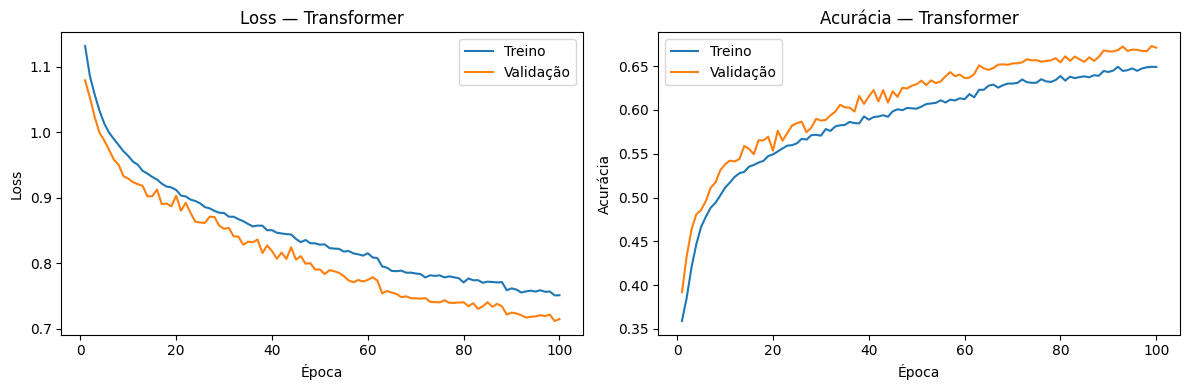

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(transformer_result.history["loss"]) + 1)

ax1.plot(epochs_ran, transformer_result.history["loss"], label="Treino")
ax1.plot(epochs_ran, transformer_result.history["val_loss"], label="Validação")
ax1.set_title("Loss — Transformer")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, transformer_result.history["accuracy"], label="Treino")
ax2.plot(epochs_ran, transformer_result.history["val_accuracy"], label="Validação")
ax2.set_title("Acurácia — Transformer")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia")
ax2.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "transformer_learning_curves.png", dpi=150)
plt.show()

### Resultado no conjunto de teste — Transformer

In [7]:
print(f"Loss no teste:     {transformer_result.test_loss:.4f}")
print(f"Acurácia no teste: {transformer_result.test_accuracy:.4f} ({transformer_result.test_accuracy * 100:.2f}%)")

Loss no teste:     0.7139
Acurácia no teste: 0.6715 (67.15%)


### Matriz de confusão — Transformer

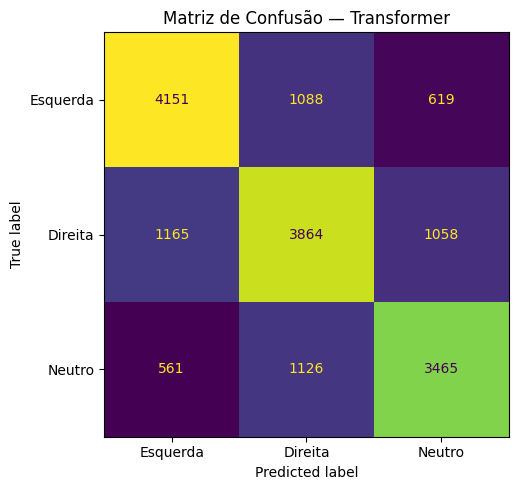

In [8]:
cm = confusion_matrix(transformer_result.y_test, transformer_result.y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Esquerda", "Direita", "Neutro"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusão — Transformer")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "transformer_confusion_matrix.png", dpi=150)
plt.show()

### Relatório de classificação — Transformer

- **Precision**: de tudo que o modelo disse ser classe X, quantos eram de fato classe X.
- **Recall**: de todas as amostras da classe X, quantas o modelo acertou.
- **F1-score**: média harmônica entre precision e recall.

In [9]:
print(classification_report(
    transformer_result.y_test,
    transformer_result.y_pred,
    target_names=["Esquerda", "Direita", "Neutro"],
))

              precision    recall  f1-score   support

    Esquerda       0.71      0.71      0.71      5858
     Direita       0.64      0.63      0.64      6087
      Neutro       0.67      0.67      0.67      5152

    accuracy                           0.67     17097
   macro avg       0.67      0.67      0.67     17097
weighted avg       0.67      0.67      0.67     17097



---
## Visualização das Attention Weights

O Transformer aprende **pesos de atenção** entre os 5 canais EEG. Visualizar a matriz de atenção média revela quais pares de eletrodos o modelo considera mais correlacionados para a classificação.

> **Nota**: A atenção é extraída da **primeira camada** (padrões mais básicos). Cada head representa uma "perspectiva" diferente sobre as relações entre canais.

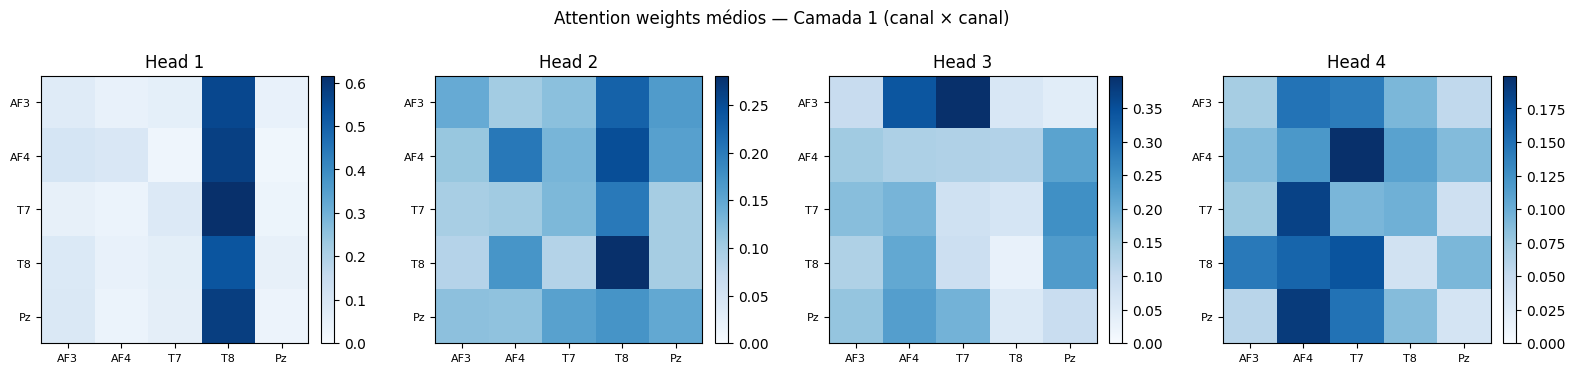

In [10]:
import tensorflow as tf
from src.models.transformer import reshape_for_transformer

CHANNEL_NAMES = ["AF3", "AF4", "T7", "T8", "Pz"]

X_test_t = reshape_for_transformer(X_test)

# Sub-model: input → output of LayerNorm just before first MHA
ln_layers  = [l for l in transformer_result.model.layers if "layer_normalization" in l.name]
mha_layers = [l for l in transformer_result.model.layers if "multi_head_attention"  in l.name]

pre_attn_model = tf.keras.Model(
    inputs=transformer_result.model.input,
    outputs=ln_layers[0].output,  # (batch, 6, d_model) — input to first MHA
)

pre_attn_out = pre_attn_model(X_test_t[:500], training=False)

# Call the first MHA layer with return_attention_scores=True to get (output, scores)
_, attn_scores = mha_layers[0](
    pre_attn_out, pre_attn_out,
    return_attention_scores=True,
    training=False,
)
attn_scores = attn_scores.numpy()  # (500, num_heads, 6, 6)

# Average over samples; extract 5×5 channel sub-matrix (skip CLS token at index 0)
attn_mean    = attn_scores.mean(axis=0)   # (num_heads, 6, 6)
attn_channel = attn_mean[:, 1:, 1:]       # (num_heads, 5, 5)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for h, ax in enumerate(axes):
    im = ax.imshow(attn_channel[h], cmap="Blues", vmin=0, vmax=attn_channel[h].max())
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(CHANNEL_NAMES, fontsize=8)
    ax.set_yticklabels(CHANNEL_NAMES, fontsize=8)
    ax.set_title(f"Head {h + 1}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Attention weights médios — Camada 1 (canal × canal)", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "transformer_attention_weights.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Comparação Final: CNN × Bi-LSTM × Bi-GRU × Transformer

CNN baseline do professor: **61.2%**. Nosso CNN: **72.70%**.

In [11]:
CNN_ACCURACY  = 0.7270
LSTM_ACCURACY = 0.6754
GRU_ACCURACY  = 0.6843

results = [
    ("CNN",         CNN_ACCURACY),
    ("Bi-LSTM",     LSTM_ACCURACY),
    ("Bi-GRU",      GRU_ACCURACY),
    ("Transformer", transformer_result.test_accuracy),
]

print(f"{'Modelo':<16} {'Acurácia':>10} {'vs CNN':>10}")
print("-" * 38)
for name, acc in results:
    delta = acc - CNN_ACCURACY
    sign = "+" if delta >= 0 else ""
    print(f"{name:<16} {acc * 100:>9.2f}%  {sign}{delta * 100:>+.2f}pp")

Modelo             Acurácia     vs CNN
--------------------------------------
CNN                  72.70%  ++0.00pp
Bi-LSTM              67.54%  -5.16pp
Bi-GRU               68.43%  -4.27pp
Transformer          67.15%  -5.55pp


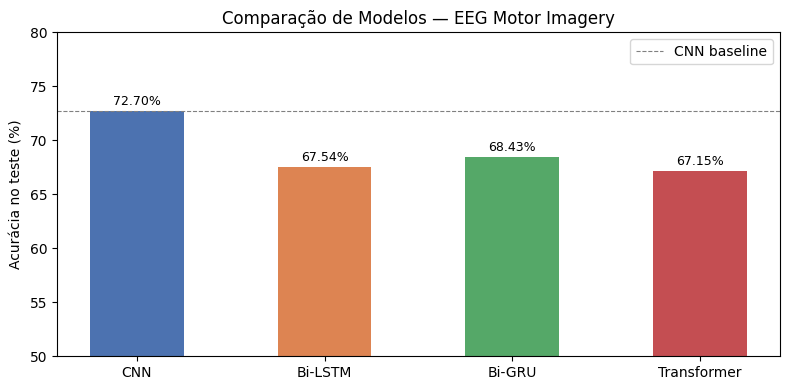

In [12]:
names = [r[0] for r in results]
accs  = [r[1] * 100 for r in results]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, accs, color=colors, width=0.5)
ax.set_ylabel("Acurácia no teste (%)")
ax.set_title("Comparação de Modelos — EEG Motor Imagery")
ax.set_ylim(50, 80)
ax.axhline(CNN_ACCURACY * 100, color="gray", linestyle="--", linewidth=0.8, label="CNN baseline")

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{acc:.2f}%", ha="center", va="bottom", fontsize=9)

ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "model_comparison.png", dpi=150)
plt.show()

## Salvar modelo

In [13]:
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

transformer_result.model.save(MODELS_DIR / "transformer_model.keras")
print("Modelo salvo em outputs/models/transformer_model.keras")

Modelo salvo em outputs/models/transformer_model.keras
